In [1]:

import networkx as nx
import numpy as np

import pylab
import matplotlib as mpl
import pandas as pd
import math

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码问题


In [2]:
source=np.array([1,2])
m=np.array([[1,2],[2,1]])
i2=np.dot(source,1/m)
i2

array([2. , 2.5])

In [3]:
1./m

array([[1. , 0.5],
       [0.5, 1. ]])

In [4]:
source1=np.array([1,0])
source2=np.array([0,2])
i1=np.dot(source1,1/m)+np.dot(source2,1/m)

# 定义qg图，是否直接继承networkxG类 属性包括：
## 画图方法，用于分析的可视化配置 输出包括：距离矩阵D or系数矩阵K +基于某个输入向量Source的输出向量Influence
## 生成距离矩阵D(1/D为距离系数矩阵K，source矩阵*K=Influence矩阵），以任一边/节点为源时的距离

In [47]:
from random import random

In [5]:
from utils import get_backbone
nodes,edges=get_backbone('煤炭')

In [6]:
nodes

[<Record n.name='合成氨' label=['Product'] backbone='种植业,石油天然气,煤炭' code=None>,
 <Record n.name='甲醇' label=['Product'] backbone='煤炭' code=None>,
 <Record n.name='二甲醚' label=['Product'] backbone='煤炭' code=None>,
 <Record n.name='热力' label=['Product'] backbone='煤炭' code=None>,
 <Record n.name='鼓风炉熔炼' label=['Technique'] backbone='煤炭' code=None>,
 <Record n.name='煤炭资源' label=['Product'] backbone='煤炭' code=None>,
 <Record n.name='醋酸' label=['Product'] backbone='煤炭' code=None>,
 <Record n.name='尿素' label=['Product'] backbone='种植业,煤炭' code=None>,
 <Record n.name='火力发电' label=['Technique'] backbone='电力,煤炭' code=None>,
 <Record n.name='动力煤' label=['Product'] backbone='电力,煤炭' code=None>,
 <Record n.name='煤矿用设备' label=['Product'] backbone='煤炭' code=None>,
 <Record n.name='粗钢' label=['Product'] backbone='钢铁,煤炭' code=None>,
 <Record n.name='焦炭' label=['Product'] backbone='石油天然气,煤炭' code=None>,
 <Record n.name='炼焦煤' label=['Product'] backbone='煤炭' code=None>,
 <Record n.name='生铁' label=['Product'] back

In [60]:
class QGDiGraph(nx.DiGraph):

    def __init__(self):
        super(QGDiGraph, self).__init__()

    def init_attr(self):
        self._num = self.number_of_edges() + self.number_of_nodes()
        self._source = np.zeros(self.num)
        self._k = np.zeros([self._num, self._num])
        self._influence = np.nan
        self._index = list(self.nodes) + list(self.edges)
        self._index2element = dict(
            zip(range(len(list(self.nodes) + list(self.edges))),
                list(self.nodes) + list(self.edges)))
        self._element2index = {v: k for k, v in self._index2element.items()}
        return self

    @property
    def index(self):
        return self._index

    @property
    def num(self):

        return self._num

    @property
    def source(self):
        return self._source

    @source.setter
    def source(self, value):
        self._source = value

    @property
    def k(self):
        return self._k

    @property
    def influence(self):
        return self._influence

    def index2element(self, index):
        '''self.index is a dict to find vertex&edges from a number ~[0,v_num+e_num]'''
        return self._index2element[index]

    def element2index(self, element):
        return self._element2index[element]

    def element2object(self, element):
        'need optimize'
        if isinstance(element, str):
            return self.nodes[element]
        else:
            return self.edges[element]

    def calc_one_k(self, element, graph):
        '''
        给定图（or子图）和其中某一元素（点or边）
        计算元素到子图中其他元素的k，
        返回{元素：k值}的字典
        对自己为1，对无路径元素为0
        '''
        k_dict = {'甲醇': 0.8, '二甲醚': 0.1, '热力': 0.6, '鼓风炉熔炼': 0.3}
        return k_dict

    def calc_k(self):
        '''
        按照传播理论，计算出以任意元素为起点，传播到其他元素的影响力系数形成系数矩阵，与距离矩阵成反比
        只对于最大联通子图进行计算（对各自子图分别计算？），非联通元素之间k为0（怎么筛选:在subgraph内计算，其他为0）
        在子图中遍历元素作为源，更新K（element）行中对子图元素的k
        element为vertex/edge时计算是否相同？
        '''
        
        subgraph = self.top1_component()

        elements = list(subgraph.nodes()) + list(subgraph.edges())
        for element in elements:
            '''对最大联通子图中元素遍历，写相应k值'''

            k_dict = self.cal_one_k(element, subgraph)
            row = self.element2index(element)
            for k, v in k_dict.items():
                self._k[row][self.element2index(k)] = v
            break

        return self.k

    def calc_i(self, source):
        self.source = source
        print(self._source)
        self._influence = np.dot(self._source, self._k)
        return self.influence

    @property
    def undirect_view(self):
        return self.to_undirected(as_view=True)

    def top1_component(self):
        undi = self.undirect_view
        top1set = max(nx.connected_components(undi), key=len)
        return self.subgraph(top1set)

    def draw(self,color_data=None,):
        cmap=plt.cm.winter_r

        #pos=nx.spring_layout(G,k=1/sqrt(len(self.G.nodes)),weight=None,scale=1,seed=20)
        pos=nx.spring_layout(self,k=1e4/self.number_of_nodes(),scale=1,seed=1,iterations=10000,threshold=1e-15)
        #pos: dict for every nodes with 2d ndarray [0.999999988, 1.33118354e-08]
        #pos['合成氨']=[9.99999988e-01, 1.33118354e-08]
        fig, ax = plt.subplots(dpi=200)
        for node,attrs in self.nodes.items():
            label=attrs['label']
            
            if 'Product' in label:
                draw_args={'nodelist':[node],'node_size':500,'node_color':"#57C7E3",'node_shape':"o",}
            #print(draw_args)
            elif 'Technique'in label:
                draw_args={'nodelist':[node],'node_size':250,'node_color':"#D9D9D9",'node_shape':"v",}
            elif 'Company' in label:
                draw_args={'nodelist':[node],'node_size':150,'node_color':"#8DCC93",'node_shape':"v",}
            else:
                draw_args={'nodelist':[node],'node_size':150,'node_color':"#000000",'node_shape':"v",}
            nx.draw_networkx_nodes(self, pos=pos,ax=ax, **draw_args)
        
        # edges
        
        edge_colors=[]
        e = [(u, v) for (u, v, attr) in self.edges(data=True) ]
        '''colors=[d['velocity'] for (u, v, d) in edges ]
        draw_args={'width':6,'edge_color':"k",'style':"solid",'alpha':None,'arrowstyle':"-|>",'arrowsize':10,'label':None,'edge_color':colors,'edge_cmap':cmap}
        edge_colors+=colors


        some data2cmap in edge dict
        '''
        #colors=[d['velocity'] for (u, v, d) in edges ]
        colors=[]
        for i in range(self.number_of_edges()):
            colors.append(random())
        draw_args={'width':2,'edge_color':"k",'style':"solid",'alpha':None,'arrowstyle':"-|>",'arrowsize':8,'label':None,'edge_color':colors,'edge_cmap':cmap}
        draw_edges=nx.draw_networkx_edges(self, pos, edgelist=e, ax=ax,**draw_args)
        




        
        # node labels
        nx.draw_networkx_labels(self, pos, font_size=10, font_family="sans-serif",ax=ax)
        # edge weight labels
        #edge_labels = nx.get_edge_attributes(self, "velocity")
        #edge_labels={k:round(v,2) for k,v in edge_labels.items()}
        #nx.draw_networkx_edge_labels(G, pos, edge_labels,ax=ax)

        ax = plt.gca()
        ax.margins(0.1)
        plt.axis("off")
        plt.tight_layout()
        pc = mpl.collections.PatchCollection(draw_edges, cmap=cmap)
        pc.set_array(edge_colors)

        ax = plt.gca()
        ax.set_axis_off()
        plt.colorbar(pc,ax=ax)
        plt.show()
        #return(draw_edges)
        pass


def init_graph(name='煤炭'):

    G = QGDiGraph()
    
    assert nx.is_directed_acyclic_graph(G)

    for node in nodes:
        G.add_node(node[0], **node[1:])
    for edge in edges:
        G.add_edge(edge[0], edge[1], relationship=edge[2])
    return G.init_attr()


G = init_graph()
print(G.undirect_view)


Graph with 62 nodes and 84 edges


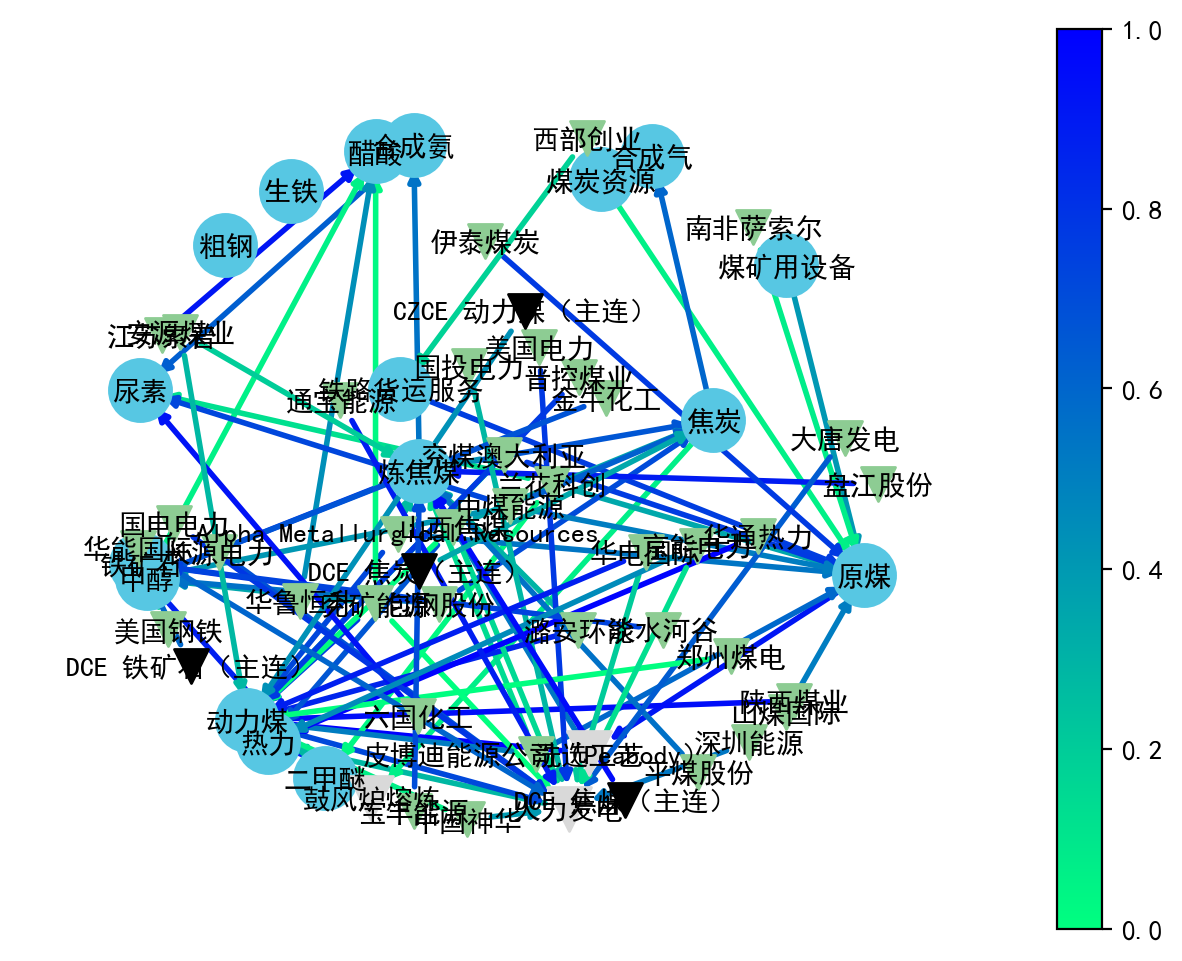

In [61]:
G.draw()

In [9]:
for name,attr in self.nodes.items():
    print(name,attr['label'])
    break

合成氨 ['Product']


In [15]:
'Product'in nodes[1].values()[1][0]

True

NetworkXError: Node 'labels(n)' has no position.

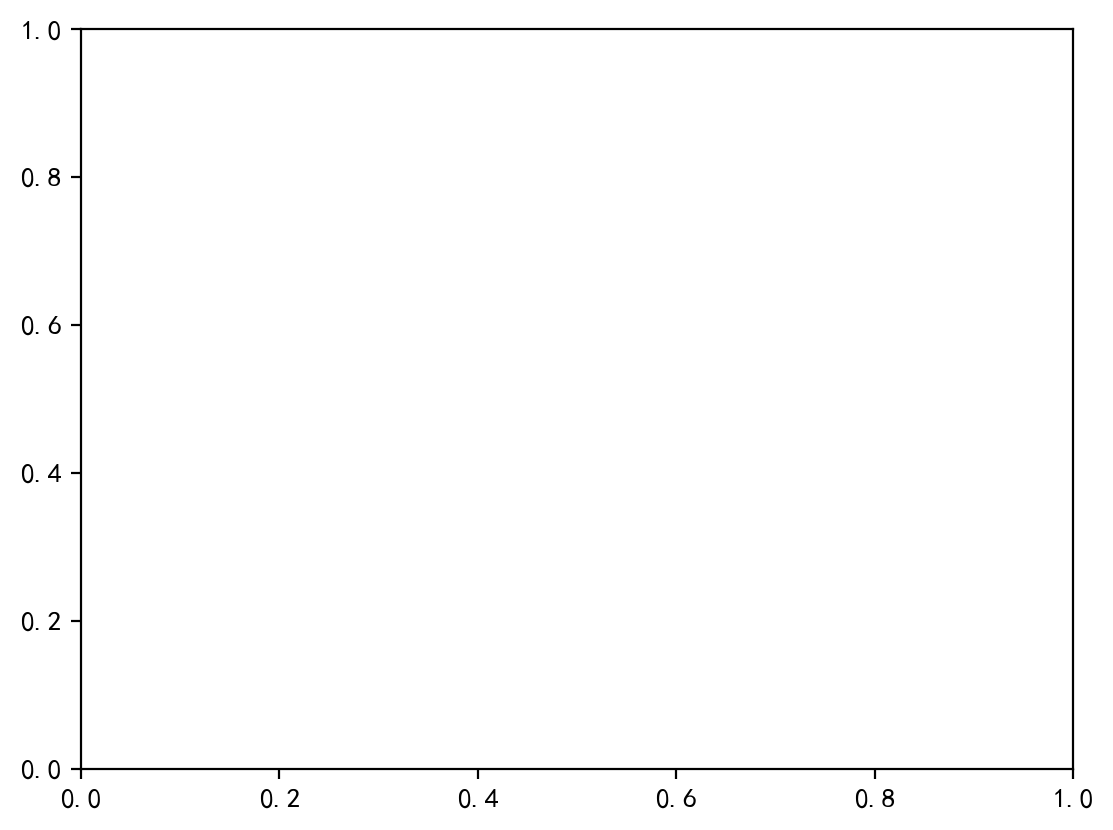

In [220]:
G.draw()

In [202]:

subgraph=G.top1_component()
subgraph.edges()
start='合成氨'

In [205]:
for n in G.neighbors(start):
    print(n)

尿素


In [212]:
G.undirect_view.edges(data=True)

EdgeDataView([('合成氨', '炼焦煤', {'relationship': 'compose'}), ('合成氨', '尿素', {'relationship': 'compose'}), ('甲醇', '兖矿能源', {'relationship': 'produce'}), ('甲醇', '二甲醚', {'relationship': 'compose'}), ('甲醇', '醋酸', {'relationship': 'compose'}), ('甲醇', '金牛化工', {'relationship': 'produce'}), ('甲醇', '包钢股份', {'relationship': 'produce'}), ('甲醇', '炼焦煤', {'relationship': 'compose'}), ('甲醇', '中煤能源', {'relationship': 'produce'}), ('二甲醚', '兰花科创', {'relationship': 'produce'}), ('热力', '山西焦煤', {'relationship': 'produce'}), ('热力', '京能电力', {'relationship': 'produce'}), ('热力', '动力煤', {'relationship': 'compose'}), ('热力', '火力发电', {'relationship': 'compose'}), ('热力', '华通热力', {'relationship': 'produce'}), ('鼓风炉熔炼', '焦炭', {'relationship': 'compose'}), ('煤炭资源', '原煤', {'relationship': 'compose'}), ('醋酸', '华鲁恒升', {'relationship': 'produce'}), ('醋酸', '兖矿能源', {'relationship': 'produce'}), ('醋酸', '江苏索普', {'relationship': 'produce'}), ('尿素', '兰花科创', {'relationship': 'produce'}), ('尿素', '中煤能源', {'relationship': 'produce'}), 

In [208]:
bfs_tree=nx.bfs_tree(G.undirect_view,start,)

In [210]:
bfs_tree.edges(data=True)

OutEdgeDataView([('合成氨', '炼焦煤', {}), ('合成氨', '尿素', {}), ('炼焦煤', '山西焦煤', {}), ('炼焦煤', '兖煤澳大利亚', {}), ('炼焦煤', '焦炭', {}), ('炼焦煤', '盘江股份', {}), ('炼焦煤', '平煤股份', {}), ('炼焦煤', '安源煤业', {}), ('炼焦煤', '宝丰能源', {}), ('炼焦煤', '皮博迪能源公司（Peabody）', {}), ('炼焦煤', '洗选工艺', {}), ('炼焦煤', 'DCE 焦煤（主连）', {}), ('炼焦煤', '潞安环能', {}), ('炼焦煤', 'Alpha Metallurgical Resources', {}), ('炼焦煤', '甲醇', {}), ('尿素', '兰花科创', {}), ('尿素', '中煤能源', {}), ('尿素', '六国化工', {}), ('山西焦煤', '动力煤', {}), ('山西焦煤', '火力发电', {}), ('山西焦煤', '热力', {}), ('兖煤澳大利亚', '原煤', {}), ('焦炭', 'DCE 焦炭（主连）', {}), ('焦炭', '包钢股份', {}), ('焦炭', '合成气', {}), ('焦炭', '鼓风炉熔炼', {}), ('甲醇', '兖矿能源', {}), ('甲醇', '二甲醚', {}), ('甲醇', '醋酸', {}), ('甲醇', '金牛化工', {}), ('动力煤', '晋控煤业', {}), ('动力煤', '陕西煤业', {}), ('动力煤', '中国神华', {}), ('动力煤', '华电国际', {}), ('动力煤', '郑州煤电', {}), ('动力煤', 'CZCE 动力煤（主连）', {}), ('火力发电', '国投电力', {}), ('火力发电', '京能电力', {}), ('火力发电', '大唐发电', {}), ('火力发电', '美国电力', {}), ('火力发电', '国电电力', {}), ('火力发电', '深圳能源', {}), ('火力发电', '长源电力', {}), ('火力发电', '华能国际', {}), ('火力发电', '通宝

In [188]:
subg=G.top1_component()
print(G.__str__())
print(subg.__str__())

QGDiGraph with 62 nodes and 84 edges
QGDiGraph with 60 nodes and 84 edges


In [190]:

G.element2object(G.index[10])

{'labels(n)': ['Product'], 'n.backbone': '煤炭', 'n.code': None}

In [149]:
a=[1,3,2]
a.sort(reverse=True)
a

[3, 2, 1]

In [152]:
s=[2,1]
s.sort()
s

[1, 2]

In [155]:
' '.join(str(c) for c in s)

'1 2'

In [74]:
undi=G.to_undirected(as_view=True)
largest_cc = max(nx.connected_components(undi), key=len)
type(largest_cc)

set

In [81]:
G.number_of_nodes()
G.subgraph(largest_cc).number_of_nodes()


60

In [73]:
print(undi._graph.__str__)
print(G.__str__)
print(undi.__str__)

<bound method Graph.__str__ of <__main__.QGDiGraph object at 0x000002888DCEB160>>
<bound method Graph.__str__ of <__main__.QGDiGraph object at 0x000002888DCEB160>>
<bound method Graph.__str__ of <networkx.classes.graph.Graph object at 0x000002888DCEB730>>


In [114]:
G1=G.to_undirected(as_view=True)

In [47]:
array=np.array([[1,2,3],[4,5,6],[7,8,9]])


array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [54]:
array.T[0]+=1
array

array([[2, 2, 3],
       [5, 5, 6],
       [8, 8, 9]])

In [96]:
G.nodes

NodeView(('合成氨', '甲醇', '二甲醚', '热力', '鼓风炉熔炼', '煤炭资源', '醋酸', '尿素', '火力发电', '动力煤', '煤矿用设备', '粗钢', '焦炭', '炼焦煤', '生铁', '铁矿石', '原煤', '洗选工艺', '合成气', '铁路货运服务', '兰花科创', '兖煤澳大利亚', 'Alpha Metallurgical Resources', '山煤国际', '兖矿能源', '江苏索普', '华鲁恒升', '包钢股份', '皮博迪能源公司（Peabody）', '南非萨索尔', '美国钢铁', '陕西煤业', '长源电力', '潞安环能', '盘江股份', '平煤股份', '山西焦煤', '中国神华', '中煤能源', '晋控煤业', '大唐发电', '深圳能源', '国投电力', '美国电力', '华通热力', '伊泰煤炭', '金牛化工', '六国化工', '郑州煤电', '国电电力', '华能国际', '淡水河谷', '华电国际', '通宝能源', '西部创业', '宝丰能源', '京能电力', '安源煤业', 'CZCE 动力煤（主连）', 'DCE 焦煤（主连）', 'DCE 焦炭（主连）', 'DCE 铁矿石（主连）'))

In [105]:
nx.has_path(G1,'合成氨','热力')

True

In [112]:
largest_cc = max(nx.connected_components(G1), key=len)
type(largest_cc)

set

In [21]:
from random import random
class Backbone_handler():
    def __init__(self,G:nx.Graph):
        self.G=G

    def nodes_group_by_label(self):
        G=self.G
        self.product={}
        self.company={}
        self.technique={}
        self.nodes={'product':self.product,'company':self.company,'technique':self.technique}
        for node,attr in G.nodes(True):
            labels=attr['labels(n)']
            if 'Product' in labels:
                self.product[node]=attr
            elif 'Company' in labels:
                self.company[node]=attr
            elif 'Technique' in labels:
                self.technique[node]=attr
        
    def edges_group_by_rela(self):
        G=self.G
        self.carry=[]
        self.compose=[]
        self.edges={'compose':self.compose,'carry':self.carry}
        for s,e,attr in G.edges(data=True):
            rela=attr['relationship']
            attr['velocity']=random()
            if 'compose' in rela:
                self.compose.append((s,e,attr))
            if 'carry' in rela:
                self.carry.append((s,e,attr))

    def draw_graph(self,frame=0):
        cmap=plt.cm.winter_r
        self.nodes_group_by_label()
        self.edges_group_by_rela()
        #pos=nx.spring_layout(G,k=1/sqrt(len(self.G.nodes)),weight=None,scale=1,seed=20)
        pos=nx.spring_layout(self.G,k=1e4/self.G.number_of_nodes(),scale=1,seed=1,iterations=10000,threshold=1e-15)
        #pos: dict for every nodes with 2d ndarray [0.999999988, 1.33118354e-08]
        #pos['合成氨']=[9.99999988e-01, 1.33118354e-08]
        fig, ax = plt.subplots(dpi=200)
        for label,nodes in self.nodes.items():
            if label=='product':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"o",}
            #print(draw_args)
            elif label=='technique':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"v",}
            nx.draw_networkx_nodes(G, pos=pos,ax=ax, **draw_args)

        # edges
        
        edge_colors=[]
        for rela,edges in self.edges.items():
                
            e = [(u, v) for (u, v, d) in edges ]
            colors=[d['velocity'] for (u, v, d) in edges ]
            draw_args={'width':6,'edge_color':"k",'style':"solid",'alpha':None,'arrowstyle':"-|>",'arrowsize':10,'label':None,'edge_color':colors,'edge_cmap':cmap}
            draw_edges=nx.draw_networkx_edges(G, pos, edgelist=e, ax=ax,**draw_args)
            edge_colors+=colors
        #edge_colors=[d['velocity'] for (u, v, d) in G.edges(data=True) ]
        
        # node labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif",ax=ax)
        # edge weight labels
        edge_labels = nx.get_edge_attributes(G, "velocity")
        edge_labels={k:round(v,2) for k,v in edge_labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels,ax=ax)

        ax = plt.gca()
        ax.margins(0.1)
        plt.axis("off")
        plt.tight_layout()
        pc = mpl.collections.PatchCollection(draw_edges, cmap=cmap)
        pc.set_array(edge_colors)

        ax = plt.gca()
        ax.set_axis_off()
        plt.colorbar(pc,ax=ax)
        plt.show()
        #return(draw_edges)
    def export_json(self):
        pass


In [22]:
class Backbone_handler():
    def __init__(self,G:nx.Graph):
        self.G=G

    def nodes_group_by_label(self):
        G=self.G
        self.product={}
        self.company={}
        self.technique={}
        self.nodes={'product':self.product,'company':self.company,'technique':self.technique}
        for node,attr in G.nodes(True):
            labels=attr['labels(n)']
            if 'Product' in labels:
                self.product[node]=attr
            elif 'Company' in labels:
                self.company[node]=attr
            elif 'Technique' in labels:
                self.technique[node]=attr
        
    def edges_group_by_rela(self):
        G=self.G
        self.carry=[]
        self.compose=[]
        self.edges={'compose':self.compose,'carry':self.carry}
        for s,e,attr in G.edges(data=True):
            rela=attr['relationship']
            attr['velocity']=random()
            if 'compose' in rela:
                self.compose.append((s,e,attr))
            if 'carry' in rela:
                self.carry.append((s,e,attr))

    def draw_graph(self,frame=0):
        cmap=plt.cm.winter_r
        self.nodes_group_by_label()
        self.edges_group_by_rela()
        #pos=nx.spring_layout(G,k=1/sqrt(len(self.G.nodes)),weight=None,scale=1,seed=20)
        pos=nx.spring_layout(self.G,k=1e4/self.G.number_of_nodes(),scale=1,seed=1,iterations=10000,threshold=1e-15)
        #pos: dict for every nodes with 2d ndarray [0.999999988, 1.33118354e-08]
        #pos['合成氨']=[9.99999988e-01, 1.33118354e-08]
        fig, ax = plt.subplots(dpi=200)
        for label,nodes in self.nodes.items():
            if label=='product':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"o",}
            #print(draw_args)
            elif label=='technique':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"v",}
            nx.draw_networkx_nodes(G, pos=pos,ax=ax, **draw_args)
        
        # edges
        
        edge_colors=[]
        for rela,edges in self.edges.items():
                
            e = [(u, v) for (u, v, d) in edges ]
            colors=[d['velocity'] for (u, v, d) in edges ]
            draw_args={'width':6,'edge_color':"k",'style':"solid",'alpha':None,'arrowstyle':"-|>",'arrowsize':10,'label':None,'edge_color':colors,'edge_cmap':cmap}
            draw_edges=nx.draw_networkx_edges(G, pos, edgelist=e, ax=ax,**draw_args)
            edge_colors+=colors
        #edge_colors=[d['velocity'] for (u, v, d) in G.edges(data=True) ]
        
        # node labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif",ax=ax)
        # edge weight labels
        edge_labels = nx.get_edge_attributes(G, "velocity")
        edge_labels={k:round(v,2) for k,v in edge_labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels,ax=ax)

        ax = plt.gca()
        ax.margins(0.1)
        plt.axis("off")
        plt.tight_layout()
        pc = mpl.collections.PatchCollection(draw_edges, cmap=cmap)
        pc.set_array(edge_colors)

        ax = plt.gca()
        ax.set_axis_off()
        plt.colorbar(pc,ax=ax)
        plt.show()
        #return(draw_edges)
    def export_json(self):
        pass


In [23]:
h=Backbone_handler(G)
h

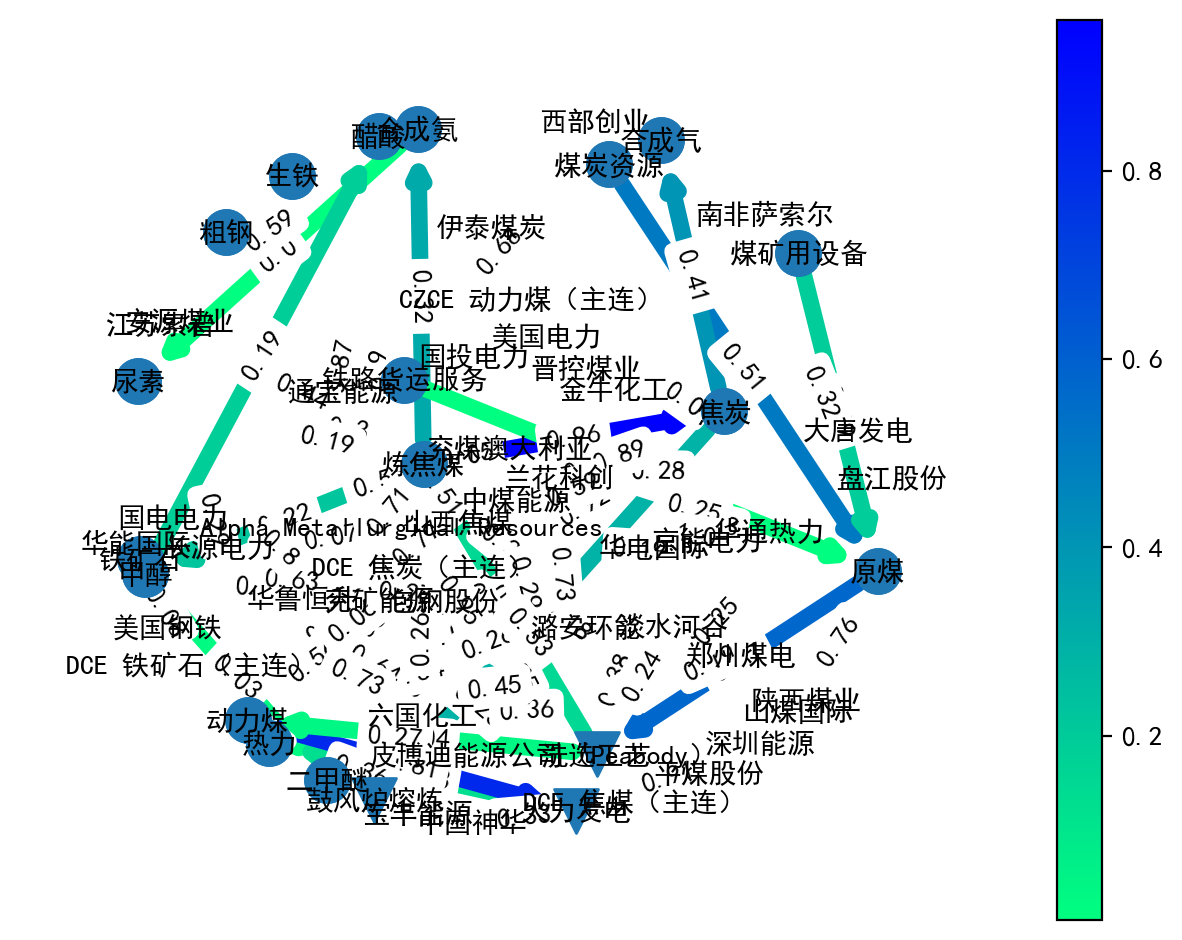

In [24]:
h.draw_graph()

In [2]:

class QGGraphError(Exception):
    #涵盖：输入电流的两节点间不边的异常
    pass
class QGNode():
    def __init__(self, name, decay=0.8, r=0) -> None:
        super().__init__()
        self.name = name
        #self.father=None
        #self.attr= production/company
        self.decay = decay  #衰减系数
        self.r = r  #r，节点净库存流
        self.nbr = {}  #neighbor+关系 par/raw/st
        self.adj = []
        self.par = []
        self.pred = []

    def update_r(self, change):
        self.r = round(self.r + change, 2)

    def get_item(self):
        return self.name

    def add_adj(self, name, re, i=0):
        self.nbr[name] = {'re': re, 'i': i}
        self.adj.append(name)

    def add_parity(self, name, re, i=0):
        self.nbr[name] = {'re': re, 'i': i}
        self.par.append(name)

    def add_pred(self, name, re, i=0):
        self.nbr[name] = {'re': re, 'i': i}
        self.pred.append(name)


In [5]:

class QGNode():
    def __init__(self, name, decay=0.8, r=0) -> None:
        super().__init__()
        self.name = name
        #self.father=None
        #self.attr= production/company
        self.decay = decay  #衰减系数
        self.r = r  #r，节点净库存流
        self.nbr = {}  #neighbor+关系 par/raw/st
        self.adj = []
        self.par = []
        self.pred = []

    def update_r(self, change):
        self.r = round(self.r + change, 2)

    def get_item(self):
        return self.name

    def add_adj(self, name, re, i=0):
        self.nbr[name] = {'re': re, 'i': i}
        self.adj.append(name)

    def add_parity(self, name, re, i=0):
        self.nbr[name] = {'re': re, 'i': i}
        self.par.append(name)

    def add_pred(self, name, re, i=0):
        self.nbr[name] = {'re': re, 'i': i}
        self.pred.append(name)

    def __dict__(self):
        return {self.name: {x for x in self.nbr}}

    def get_r(self):
        return self.r

    def get_edge_list(self):
        # ('B', 'A', {'re': 'raw','i': 0}),
        edge_list = []
        for neighbor in self.nbr:
            edge_list.append((self.name, neighbor, self.nbr[neighbor]))
        return edge_list


class QGGraph():
    def __init__(self, ):
        self.node_dict = {}
        self.edge_dict = {}
        self.updated_node_list = []
        self.node_i_out_dict = {}
        self.updated_edge_list = []
        self.num_nodes = 0
        self.num_edges = 0
        self.c_par = -0.5
        self.c_node = 0.8
        self.source=True
        self.source_node = ''
        self.source_input = 0

    #构建和检索部分
    def add_Node(self, name):
        new_Node = QGNode(name)
        self.node_dict[name] = new_Node
        self.num_nodes += 1
        return new_Node

    def get_Node(self, name) -> dict:
        if name in self.node_dict:
            return self.node_dict[name]
        else:
            return None

    def get_all_Nodes(self) -> dict:
        dic = {}
        for node in self.node_dict:
            dic[node] = self.node_dict[node].get_r()
        return dic

    def add_Edge(self, f, t, re, i):
        if f not in self.node_dict:
            nn = self.add_Node(f)
        if t not in self.node_dict:
            nn = self.add_Node(t)
        if re in ('raw', 'st'):
            self.node_dict[f].add_adj(t, re, i)
            self.node_dict[t].add_pred(f, re, i)
        if re == 'par':
            self.node_dict[f].add_parity(t, re, i)
            self.node_dict[t].add_parity(f, re, i)
        self.edge_dict[(f, t)] = {
            're': re,
            'i': i
        }  #在图里保存并更新所有边的信息,点只存变量r，不存边的i
        self.num_edges += 1

    def get_all_Edges(self):
        return self.edge_dict

    # networkx 可视化部分
    def build_nx_dic(self):
        nx_node_list = []
        for n in self.node_dict:
            dic = {'node': self.node_dict[n], 'r': self.node_dict[n].get_r()}
            nx_node_list.append((n, dic))
        nx_edge_list = []
        for e in self.edge_dict:
            f, t = e
            nx_edge_list.append((f, t, self.edge_dict[e]))
        return nx_node_list, nx_edge_list

    def build_networkx(self):
        node, edge = self.build_nx_dic()
        G = nx.DiGraph()
        G.add_nodes_from(node)
        G.add_edges_from(edge)
        return G

    def draw_networkx(self):
        G = self.build_networkx()

        options = {
            "font_size": 15,
            "node_size": 1100,
            "node_color": "w",
            "edgecolors": "black",
            "linewidths": 0.5,
            "width": 1,
        }
        fig, ax = plt.subplots(dpi=200)
        pos = nx.spring_layout(G, 50/G.number_of_nodes(),
                               seed=6)  # Seed layout for reproducibility
        nx.draw(
            G,
            pos,
            **options,ax=ax
        )
        node_labels = {}
        for node in G.nodes:
            node_labels[node] = str(node) + ': ' + str(G.nodes[node]['r'])
        nx.draw_networkx_labels(G, pos, labels=node_labels)
        edge_labels = {}
        for edge in G.edges:
            edge_labels[edge] = str(G[edge[0]][edge[1]]['re']) + ' ' + str(
                G[edge[0]][edge[1]]['i'])
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
        if self.source:
            options1 = {
            
            "node_size": 1100,
            "node_color": "blue",

        }
            nx.draw_networkx_nodes(G,pos,nodelist=['A'],**options1,ax=ax)
            pass
        else:
            pass
        plt.show()
        return G

    # 计算、更新部分
    #轮子
    def update_Edge(self, f, t, i):
        if (f, t) in self.edge_dict:
            assert (f, t) not in self.updated_edge_list, ('该边已被更新过:', f, t)
            self.edge_dict[f, t]['i'] = round(i + self.edge_dict[f, t]['i'], 2)
            self.updated_edge_list.append((f, t))
        elif (t, f) in self.edge_dict:
            assert (t, f) not in self.updated_edge_list, ('该边已被更新过:', t, f)
            self.edge_dict[t, f]['i'] = round(i + self.edge_dict[t, f]['i'], 2)
            self.updated_edge_list.append((t, f))
        else:
            raise QGGraphError('更新的边不在图中存在:', f, t)

    def update_Node(self, name, r):
        assert name in self.node_dict, ('该节点不在图中:', name)
        assert name not in self.updated_node_list, ('该节点已被更新:', name)
        self.node_dict[name].update_r(r)
        self.updated_node_list.append(name)

    def get_pred_par(self, name):

        #假定互为同位的节点被全部输入，即两两间都为同位关系,获得分组列表
        query = []
        result = []
        for pred in self.node_dict[name].pred:
            group = [pred]
            if pred not in query:
                for par in self.node_dict[pred].par:
                    if par not in query:
                        if name in self.node_dict[par].adj:
                            group.append(par)
                            query.append(par)
                result.append(group)
                query.append(pred)
        return result
        
    def get_adj_par(self, name):
        query = []
        result = []
        for adj in self.node_dict[name].adj:
            group = [adj]
            if adj not in query:
                for par in self.node_dict[adj].par:
                    if par not in query:
                        if name in self.node_dict[par].pred:
                            group.append(par)
                            query.append(par)
                result.append(group)
                query.append(adj)
        return result

    #输入和响应
    def update_graph(self, input):
        self.add_source(input)
        self.source_node = input['f']
        self.source_input = input['i']
        q = [input['t']]
        while len(q) > 0:
            current = q.pop(0)
            nbr = []
            #print(current)
            #print(q)
            for adj in self.node_dict[current].adj:
                if adj not in self.updated_node_list:
                    q.append(adj)
                    #print(current,adj,self.edge_dict[current,adj]['i'])
                    self.update(f=current,
                                t=adj,
                                i_in=self.edge_dict[current, adj]['i'])
                for pred in self.node_dict[current].pred:
                    if pred not in self.updated_node_list:
                        q.append(pred)
                        #print(pred,current,self.edge_dict[pred,current]['i'])
                        self.update(f=current,
                                    t=pred,
                                    i_in=self.edge_dict[pred, current]['i'])
                '''for n in nbr:
                    q.append(n)
                    self.update(f=current,t=n,i_in=self.edge_dict[(current,n)])'''
        print('本次输入更新的边为:', self.updated_edge_list)
        print('本次输入更新的点为:', self.updated_node_list)
        self.updated_node_list = []
        self.updated_edge_list = []

    def add_source(self, input):
        #input={'f':'B','t':'A','i':20}
        f = input['f']
        t = input['t']
        i = input['i']
        self.source=(f,t,i)
        self.update(f=f, t=t, i_in=i)

    def bfs(self, start):
        q = [start]
        over = []
        #start,i_out=
        while len(q) > 0:
            #if q[0] not in over:

            current = q.pop(0)

            print(current)
            nbr = []
            for adj in self.node_dict[current].adj:
                if adj not in self.updated_node_list:
                    nbr.append(adj)
            for pred in self.node_dict[current].pred:
                if pred not in self.updated_node_list:
                    nbr.append(pred)
            for n in nbr:
                print(n)
                q.append(n, )

                self.updated_node_list.append(n)
                #print(self.updated_node_list)
            over.append(current)

    def update(self, f, t, i_in) -> None:

        #先分组，再计算，再递归传导
        #对一个点产生影响的只有一个源（或者经过同位衰减的一组源）
        #f='b',t='a',i_in=20
        #此处f，t为影响力传播，非边的方向,i为ft之间的影响力，同时为t的i_in更新前的初值
        #只对t更新，然后由t传播(与边的方向无关)
        if t == self.source_node:
            i_in = self.source_input

        c_node = self.c_node
        c_par = self.c_par
        preds = self.get_pred_par(t)
        adjs = self.get_adj_par(t)
        print(t,adjs)
        f_node = self.node_dict[f]
        t_node = self.node_dict[t]
        if f in t_node.pred:
            #f为t的上游时，f-t是源，找上游组
            for group in preds:
                if f in group:
                    if len(group) > 1:
                        group.remove(f)
                        for other in group:
                            if (other, t) not in self.updated_edge_list:
                                self.update_Edge(
                                    other, t,
                                    round(c_par * i_in / len(group), 2))
                                i_in += round(c_par * i_in / len(group), 2)
                            else:

                                i_in += round(self.edge_dict[(other, t)]['i'],
                                              2)

        else:
            #否则相反，找下游组

            for group in adjs:
                
                if f in group:
                    print(group)
                    if len(group) > 1:

                        group.remove(f)
                        for other in group:
                            if (t, other) not in self.updated_edge_list:
                                self.update_Edge(
                                    t, other,
                                    round(c_par * i_in / len(group), 2))
                                i_in += round(c_par * i_in / len(group), 2)
                                #print('trigger', i_in)
                            else:
                                i_in += round(self.edge_dict[(t, other)]['i'],
                                              2)
                                #print('trigger', i_in)
        print(t, i_in)
        #更新ir
        if t not in self.updated_node_list:
            #print(t,round(i_in*(1-c_node),2))
            self.update_Node(t, r=round(i_in * (1 - c_node), 2))
        else:
            pass
        #对其他所有组更新iout
        i_out = round(i_in * c_node, 2)
        self.node_i_out_dict[t] = i_out
        for group in preds:
            num = len(group)
            for other in group:
                if (other, t) not in self.updated_edge_list:
                    self.update_Edge(other, t, round(i_out / num, 2))
        for group in adjs:
            num = len(group)
            for other in group:
                if (t, other) not in self.updated_edge_list:
                    self.update_Edge(t, other, round(i_out / num, 2))
        #更新相邻节点 #BFS

{'A': 0, 'B': 0, 'C': 0, 'D': 0, 'E': 0, 'F': 0, 'G': 0, 'H': 0, 'I': 0, 'J': 0, 'K': 0, 'L': 0, 'M': 0, 'N': 0, 'O': 0, 'P': 0, 'Q': 0}
{('B', 'A'): {'re': 'raw', 'i': 0}, ('C', 'A'): {'re': 'raw', 'i': 0}, ('D', 'A'): {'re': 'raw', 'i': 0}, ('E', 'A'): {'re': 'raw', 'i': 0}, ('F', 'A'): {'re': 'raw', 'i': 0}, ('G', 'A'): {'re': 'raw', 'i': 0}, ('K', 'G'): {'re': 'raw', 'i': 0}, ('A', 'I'): {'re': 'raw', 'i': 0}, ('A', 'J'): {'re': 'st', 'i': 0}, ('H', 'I'): {'re': 'raw', 'i': 0}, ('I', 'L'): {'re': 'raw', 'i': 0}, ('L', 'M'): {'re': 'raw', 'i': 0}, ('B', 'C'): {'re': 'par', 'i': 0}, ('A', 'H'): {'re': 'par', 'i': 0}, ('E', 'F'): {'re': 'par', 'i': 0}, ('F', 'K'): {'re': 'par', 'i': 0}, ('P', 'C'): {'re': 'raw', 'i': 0}, ('B', 'N'): {'re': 'raw', 'i': 0}, ('O', 'B'): {'re': 'raw', 'i': 0}, ('Q', 'B'): {'re': 'raw', 'i': 0}, ('Q', 'C'): {'re': 'raw', 'i': 0}}


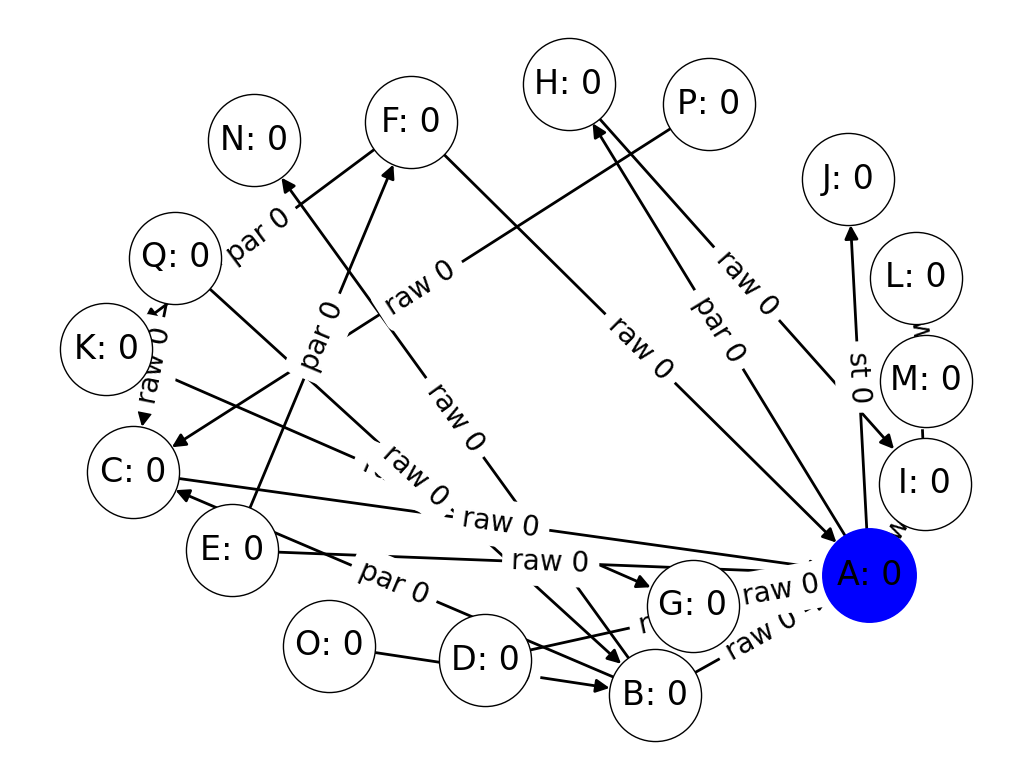

In [6]:
nodes_list = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O',
    'P', 'Q'
]
g=QGGraph()
for n in nodes_list:
    g.add_Node(n)

whole_edges_list = [
    ('B', 'A', {
        're': 'raw',
        'i': 0
    }),
    ('C', 'A', {
        're': 'raw',
        'i': 0
    }),
    ('D', 'A', {
        're': 'raw',
        'i': 0
    }),
    ('E', 'A', {
        're': 'raw',
        'i': 0
    }),
    ('F', 'A', {
        're': 'raw',
        'i': 0
    }),
    ('G', 'A', {
        're': 'raw',
        'i': 0
    }),
    ('K', 'G', {
        're': 'raw',
        'i': 0
    }),
    ('A', 'I', {
        're': 'raw',
        'i': 0
    }),
    ('A', 'J', {
        're': 'st',
        'i': 0
    }),
    ('H', 'I', {
        're': 'raw',
        'i': 0
    }),
    ('I', 'L', {
        're': 'raw',
        'i': 0
    }),
    ('L', 'M', {
        're': 'raw',
        'i': 0
    }),
    ('B', 'C', {
        're': 'par',
        'i': 0
    }),
    ('A', 'H', {
        're': 'par',
        'i': 0
    }),
    ('E', 'F', {
        're': 'par',
        'i': 0
    }),
    ('F', 'K', {
        're': 'par',
        'i': 0
    }),
    ('P', 'C', {
        're': 'raw',
        'i': 0
    }),
    ('B', 'N', {
        're': 'raw',
        'i': 0
    }),
    ('O', 'B', {
        're': 'raw',
        'i': 0
    }),
    ('Q', 'B', {
        're': 'raw',
        'i': 0
    }),
    ('Q', 'C', {
        're': 'raw',
        'i': 0
    }),
]
for l in whole_edges_list:
    g.add_Edge(f=l[0],t=l[1],re=l[2]['re'],i=l[2]['i'])

#g.draw_networkx()
print(g.get_all_Nodes())
print(g.get_all_Edges())

#g.update_graph(input={'f': 'B', 't': 'A', 'i': 20})
#g.add_source(input={'f': 'B', 't': 'A', 'i': 20})
G=g.draw_networkx()

In [7]:
list(G)

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q']

In [8]:
range(17)

range(0, 17)